In [1]:
# Resolve project paths when launched from the root or a project subfolder.
from pathlib import Path

PROJECT_ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (p / "trial_manifest.json").is_file() and (p / "analysis").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Launch this notebook from the new G&P project folder or analysis folder.")
DATA_ROOT = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


### Can gait-based person identification maintain similar performance using a lower-dimensional representation?

In [2]:
# CELL 1 — Imports

from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

print("Imports complete.")

C:\Users\MSI\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Imports complete.


In [3]:
# CELL 2 — Load cycle-level features

FEATURE_FILE = RESULTS_DIR / "cycle_features_with_quality.csv"

df = pd.read_csv(FEATURE_FILE)

print("Dataset shape:", df.shape)
print("\nPeople:")
print(df["person"].value_counts())

print("\nColumns:", len(df.columns))

Dataset shape: (435, 97)

People:
person
Thenuri     145
Nadeera     124
Buddhini     77
Harshika     59
Muthuni      30
Name: count, dtype: int64

Columns: 97


In [4]:
# CELL 3 — Define model features

metadata_cols = [
    "person",
    "trial",
    "phase",
    "cycle_index",
    "frames",
    "quality_flag"
]

feature_cols = [
    col for col in df.columns
    if "__" in col or col == "duration"
]

print("Number of model features:", len(feature_cols))

assert len(feature_cols) == 91, (
    f"Expected 91 features, found {len(feature_cols)}"
)

# Check validity
assert df[feature_cols].isna().sum().sum() == 0
assert np.isfinite(df[feature_cols].to_numpy()).all()

print("✓ 91 numeric features ready.")

Number of model features: 91
✓ 91 numeric features ready.


In [5]:
# CELL 4 — Define independent trial groups

df["group_id"] = (
    df["person"].astype(str)
    + "_T"
    + df["trial"].astype(str)
)

persons = sorted(df["person"].unique())

trials_by_person = {
    person: sorted(
        df.loc[df["person"] == person, "trial"].unique()
    )
    for person in persons
}

print("Independent trials:")

for person in persons:
    print(
        f"{person:10s}: "
        f"{trials_by_person[person]}"
    )

print(
    "\nTotal independent recordings:",
    df["group_id"].nunique()
)

Independent trials:
Buddhini  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(9)]
Harshika  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Muthuni   : [np.int64(1), np.int64(2), np.int64(3)]
Nadeera   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Thenuri   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Total independent recordings: 22


In [6]:
# CELL 5 — Generate exhaustive trial-holdout combinations

exhaustive_combinations = list(
    product(
        *[
            trials_by_person[person]
            for person in persons
        ]
    )
)

print(
    "Number of exhaustive holdout combinations:",
    len(exhaustive_combinations)
)

assert len(exhaustive_combinations) == 1440

print("✓ 1,440 trial-holdout combinations generated.")

Number of exhaustive holdout combinations: 1440
✓ 1,440 trial-holdout combinations generated.


In [7]:
# CELL 6 — Model B: PCA + Linear SVM

def create_pca_svm():

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),

        (
            "pca",
            PCA(
                n_components=0.95,
                svd_solver="full"
            )
        ),

        (
            "svm",
            SVC(
                kernel="linear",
                C=1.0,
                class_weight="balanced"
            )
        )
    ])


model_b = create_pca_svm()

print(model_b)

Pipeline(steps=[('scaler', StandardScaler()),
                ('pca', PCA(n_components=0.95, svd_solver='full')),
                ('svm', SVC(class_weight='balanced', kernel='linear'))])


In [8]:
# CELL 7 — Exhaustive evaluation of PCA + Linear SVM

pca_results = []
pca_trial_predictions = []

for split_id, heldout_trials in enumerate(
    exhaustive_combinations,
    start=1
):

    test_mask = np.zeros(
        len(df),
        dtype=bool
    )

    # Hold out one complete trial from every person
    for person, trial in zip(
        persons,
        heldout_trials
    ):

        test_mask |= (
            (df["person"] == person)
            &
            (df["trial"] == trial)
        ).to_numpy()

    train_df = df.loc[~test_mask].copy()
    test_df = df.loc[test_mask].copy()

    X_train = train_df[feature_cols]
    y_train = train_df["person"]

    X_test = test_df[feature_cols]
    y_test = test_df["person"]

    # Create a NEW pipeline for every split
    model = create_pca_svm()

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(X_test)

    # Number of PCA components selected
    n_components = (
        model
        .named_steps["pca"]
        .n_components_
    )

    explained_variance = (
        model
        .named_steps["pca"]
        .explained_variance_ratio_
        .sum()
    )

    # Cycle-level results
    pca_results.append({
        "split": split_id,
        "accuracy":
            accuracy_score(y_test, y_pred),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_test,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_test,
                y_pred,
                average="macro"
            ),

        "n_components":
            n_components,

        "explained_variance":
            explained_variance
    })

    # Trial-level majority voting
    prediction_df = test_df[
        [
            "person",
            "trial",
            "group_id"
        ]
    ].copy()

    prediction_df["predicted_person"] = y_pred

    for (
        person,
        trial,
        group_id
    ), group in prediction_df.groupby(
        [
            "person",
            "trial",
            "group_id"
        ]
    ):

        predicted_person = (
            group["predicted_person"]
            .value_counts()
            .idxmax()
        )

        pca_trial_predictions.append({
            "split": split_id,
            "person": person,
            "trial": trial,
            "group_id": group_id,
            "predicted_person":
                predicted_person,
            "correct":
                predicted_person == person
        })


pca_results_df = pd.DataFrame(
    pca_results
)

pca_trial_predictions_df = pd.DataFrame(
    pca_trial_predictions
)

print("✓ Model B evaluation complete.")
print(
    "Splits evaluated:",
    len(pca_results_df)
)

✓ Model B evaluation complete.
Splits evaluated: 1440


In [9]:
# CELL 8 — Model B performance summary

print("=" * 60)
print("MODEL B — PCA + LINEAR SVM")
print("=" * 60)

display(
    pca_results_df[
        [
            "accuracy",
            "balanced_accuracy",
            "macro_f1"
        ]
    ].describe().round(4)
)

print("\nPCA dimensionality:")

display(
    pca_results_df[
        [
            "n_components",
            "explained_variance"
        ]
    ].describe().round(4)
)

MODEL B — PCA + LINEAR SVM


,accuracy,balanced_accuracy,macro_f1
count,1440.0000,1440.0000,1440.0000
mean,0.9562,0.9398,0.9381
std,0.0293,0.0421,0.0420
min,0.8182,0.7564,0.7406
25%,0.9462,0.9181,0.9180
50%,0.9596,0.9459,0.9459
75%,0.9747,0.9683,0.9658
max,1.0000,1.0000,1.0000



PCA dimensionality:


,n_components,explained_variance
count,1440.0000,1440.0000
mean,26.1736,0.9523
std,0.5957,0.0014
min,25.0000,0.9500
25%,26.0000,0.9511
50%,26.0000,0.9523
75%,27.0000,0.9536
max,28.0000,0.9548


In [10]:
# CELL 9 — Trial-level identification robustness

trial_stability_pca = (
    pca_trial_predictions_df
    .groupby(
        ["person", "trial"]
    )["correct"]
    .agg(
        correct_count="sum",
        total_tests="count"
    )
    .reset_index()
)

trial_stability_pca["correct_pct"] = (
    100
    * trial_stability_pca["correct_count"]
    / trial_stability_pca["total_tests"]
)

display(
    trial_stability_pca.round(2)
)

,person,trial,correct_count,total_tests,correct_pct
0,Buddhini,1,240,240,100.00
1,Buddhini,2,240,240,100.00
2,Buddhini,3,240,240,100.00
3,Buddhini,4,240,240,100.00
4,Buddhini,7,199,240,82.92
5,Buddhini,9,240,240,100.00
6,Harshika,1,288,288,100.00
7,Harshika,2,288,288,100.00
8,Harshika,3,288,288,100.00
9,Harshika,4,288,288,100.00


In [11]:
# CELL 10 — Save Model B results

pca_results_df.to_csv(
    RESULTS_DIR / "pca_svm_exhaustive_results.csv",
    index=False
)

pca_trial_predictions_df.to_csv(
    RESULTS_DIR / "pca_svm_trial_predictions.csv",
    index=False
)

trial_stability_pca.to_csv(
    RESULTS_DIR / "pca_svm_trial_stability.csv",
    index=False
)

print("✓ Model B results saved.")

✓ Model B results saved.


PCA reduced the representation from 91 features to only 25–28 principal components, averaging 26.17 components, while accuracy decreased by only 0.74 percentage points.

PCA removed roughly 71% of the input dimensions while retaining about 95% of the variance and preserving most of the classification performance.

In [12]:
# CELL 11 — Model A vs Model B comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Model A — No dimensionality reduction",
        "Model B — PCA (95% variance)"
    ],

    "Mean dimensions": [
        91,
        pca_results_df["n_components"].mean()
    ],

    "Accuracy (%)": [
        96.36,
        pca_results_df["accuracy"].mean() * 100
    ],

    "Balanced accuracy (%)": [
        95.04,
        pca_results_df["balanced_accuracy"].mean() * 100
    ],

    "Macro F1 (%)": [
        94.82,
        pca_results_df["macro_f1"].mean() * 100
    ]
})

display(model_comparison.round(2))

,Model,Mean dimensions,Accuracy (%),Balanced accuracy (%),Macro F1 (%)
0,Model A — No dimensionality reduction,91.00,96.36,95.04,94.82
1,Model B — PCA (95% variance),26.17,95.62,93.98,93.81


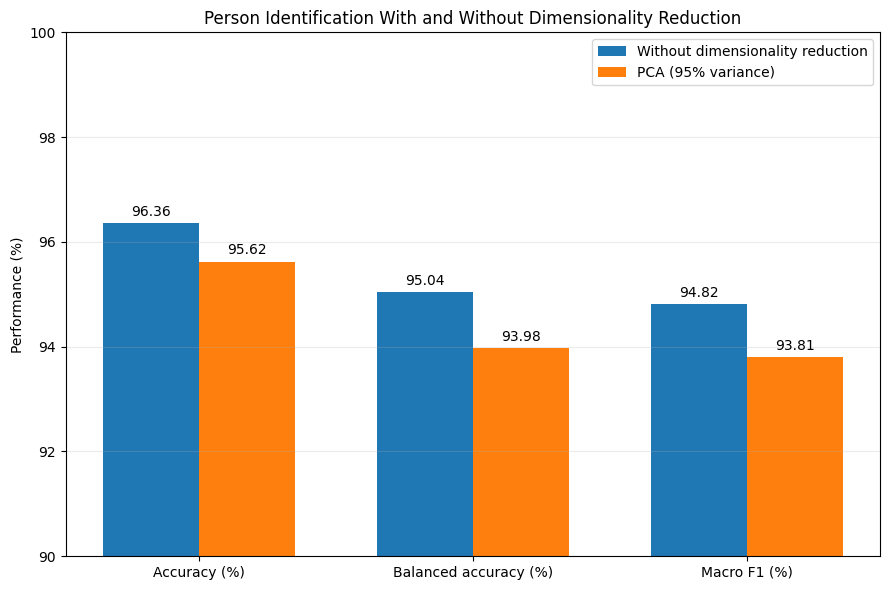

In [13]:
# CELL 12 — Performance comparison plot

metrics = [
    "Accuracy (%)",
    "Balanced accuracy (%)",
    "Macro F1 (%)"
]

model_a = [
    96.36,
    95.04,
    94.82
]

model_b = [
    pca_results_df["accuracy"].mean() * 100,
    pca_results_df["balanced_accuracy"].mean() * 100,
    pca_results_df["macro_f1"].mean() * 100
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

bars_a = ax.bar(
    x - width/2,
    model_a,
    width,
    label="Without dimensionality reduction"
)

bars_b = ax.bar(
    x + width/2,
    model_b,
    width,
    label="PCA (95% variance)"
)

ax.set_ylabel("Performance (%)")
ax.set_title(
    "Person Identification With and Without "
    "Dimensionality Reduction"
)

ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.set_ylim(90, 100)

ax.legend()
ax.grid(axis="y", alpha=0.25)

ax.bar_label(
    bars_a,
    fmt="%.2f",
    padding=3
)

ax.bar_label(
    bars_b,
    fmt="%.2f",
    padding=3
)

plt.tight_layout()
plt.show()

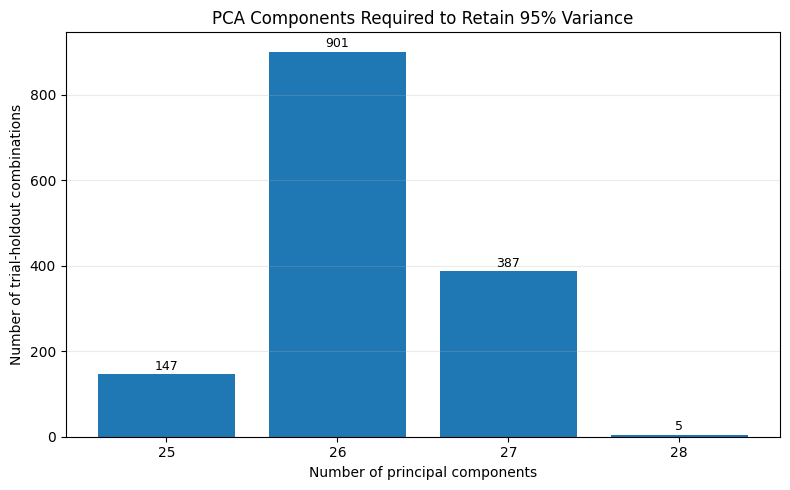

Mean components: 26.17
Range: 25–28


In [14]:
# CELL 13 — Number of PCA components across trial splits

component_counts = (
    pca_results_df["n_components"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    component_counts.index.astype(str),
    component_counts.values
)

ax.set_xlabel("Number of principal components")
ax.set_ylabel("Number of trial-holdout combinations")

ax.set_title(
    "PCA Components Required to Retain 95% Variance"
)

ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, component_counts.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 10,
        str(value),
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

print(
    f"Mean components: "
    f"{pca_results_df['n_components'].mean():.2f}"
)

print(
    f"Range: "
    f"{pca_results_df['n_components'].min()}–"
    f"{pca_results_df['n_components'].max()}"
)

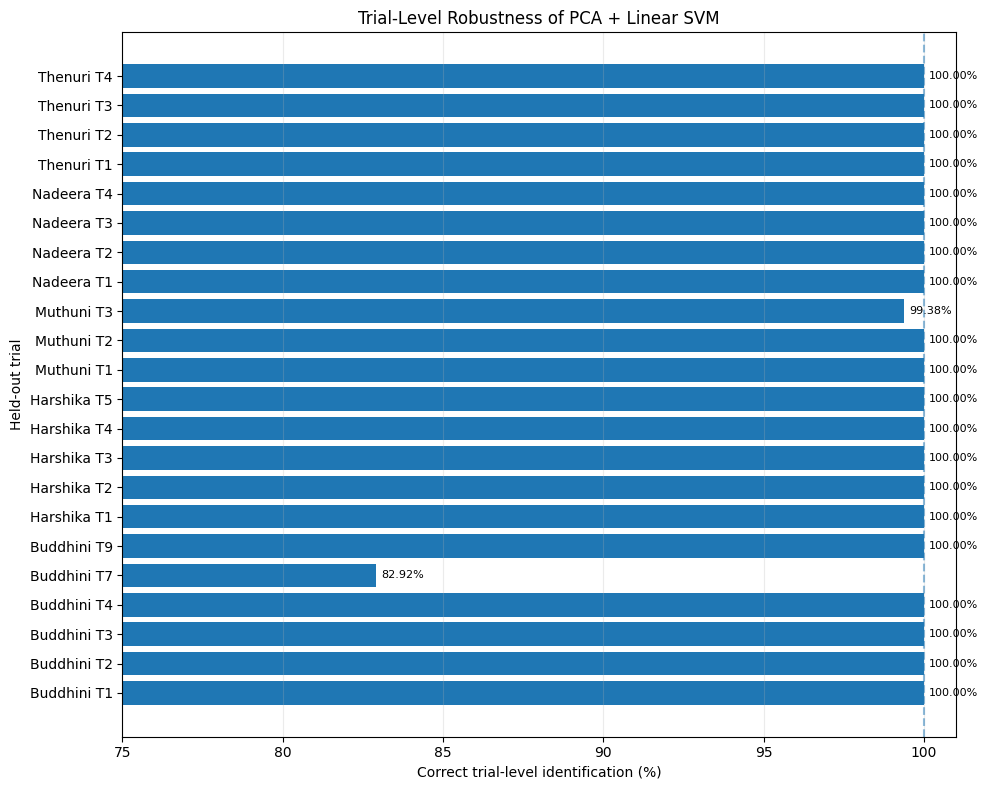

In [15]:
# CELL 14 — PCA trial-level robustness

trial_plot = trial_stability_pca.copy()

trial_plot["label"] = (
    trial_plot["person"].astype(str)
    + " T"
    + trial_plot["trial"].astype(str)
)

trial_plot = trial_plot.sort_values(
    ["person", "trial"]
)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    trial_plot["label"],
    trial_plot["correct_pct"]
)

ax.set_xlabel(
    "Correct trial-level identification (%)"
)

ax.set_ylabel("Held-out trial")

ax.set_title(
    "Trial-Level Robustness of PCA + Linear SVM"
)

ax.set_xlim(75, 101)

ax.axvline(
    100,
    linestyle="--",
    alpha=0.5
)

ax.grid(axis="x", alpha=0.25)

for bar, value in zip(
    bars,
    trial_plot["correct_pct"]
):
    ax.text(
        value + 0.15,
        bar.get_y() + bar.get_height()/2,
        f"{value:.2f}%",
        va="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [16]:
# CELL 15 — Dimensionality reduction summary

original_dimensions = 91

mean_pca_dimensions = (
    pca_results_df["n_components"].mean()
)

dimension_reduction = (
    1 -
    mean_pca_dimensions / original_dimensions
) * 100

accuracy_loss = (
    96.36 -
    pca_results_df["accuracy"].mean() * 100
)

print("=" * 60)
print("DIMENSIONALITY REDUCTION SUMMARY")
print("=" * 60)

print(
    f"Original dimensions       : "
    f"{original_dimensions}"
)

print(
    f"Mean PCA dimensions       : "
    f"{mean_pca_dimensions:.2f}"
)

print(
    f"Dimension reduction       : "
    f"{dimension_reduction:.2f}%"
)

print(
    f"Mean variance retained    : "
    f"{pca_results_df['explained_variance'].mean()*100:.2f}%"
)

print(
    f"Model A accuracy          : "
    f"96.36%"
)

print(
    f"Model B accuracy          : "
    f"{pca_results_df['accuracy'].mean()*100:.2f}%"
)

print(
    f"Accuracy difference       : "
    f"-{accuracy_loss:.2f} percentage points"
)

DIMENSIONALITY REDUCTION SUMMARY
Original dimensions       : 91
Mean PCA dimensions       : 26.17
Dimension reduction       : 71.24%
Mean variance retained    : 95.23%
Model A accuracy          : 96.36%
Model B accuracy          : 95.62%
Accuracy difference       : -0.74 percentage points


### Without dimensionality reduction: the 91-feature Linear SVM achieved 96.36% mean accuracy.

### With dimensionality reduction: PCA reduced the representation to approximately 26 components (71.24% fewer dimensions) while retaining 95.23% variance, and the Linear SVM still achieved 95.62% mean accuracy.